<a href="https://colab.research.google.com/github/Sk8133/Explainable-AI/blob/main/zikavirus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import pandas library
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/cdc_zika.csv")

# Print the entire dataset
print(df)

# (Optional) – To just view the first 5 rows for quick look
# print(df.head())


       report_date                      location location_type  \
0       2016-03-19        Argentina-Buenos_Aires      province   
1       2016-03-19        Argentina-Buenos_Aires      province   
2       2016-03-19        Argentina-Buenos_Aires      province   
3       2016-03-19        Argentina-Buenos_Aires      province   
4       2016-03-19        Argentina-Buenos_Aires      province   
...            ...                           ...           ...   
107614  2016-06-28  United_States_Virgin_Islands     territory   
107615  2016-06-28  United_States_Virgin_Islands     territory   
107616  2016-06-28  United_States_Virgin_Islands     territory   
107617  2016-06-28  United_States_Virgin_Islands     territory   
107618  2016-06-28  United_States_Virgin_Islands     territory   

                                 data_field data_field_code  time_period  \
0          cumulative_confirmed_local_cases          AR0001          NaN   
1           cumulative_probable_local_cases          AR

/tmp/ipython-input-1669975698.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/cdc_zika.csv")


In [ ]:
import pandas as pd

# Load the dataset with low_memory=False to avoid dtype warnings
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False)

# Convert all string/object columns to numeric (non-convertible values become NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Print the first few rows to confirm conversion
print(df.head())

# Optional: Check data types after conversion
print("\nData types after conversion:\n", df.dtypes)


   report_date  location  location_type  data_field  data_field_code  \
0          NaN       NaN            NaN         NaN              NaN   
1          NaN       NaN            NaN         NaN              NaN   
2          NaN       NaN            NaN         NaN              NaN   
3          NaN       NaN            NaN         NaN              NaN   
4          NaN       NaN            NaN         NaN              NaN   

   time_period  time_period_type  value  unit  
0          NaN               NaN    0.0   NaN  
1          NaN               NaN    0.0   NaN  
2          NaN               NaN    2.0   NaN  
3          NaN               NaN    1.0   NaN  
4          NaN               NaN  127.0   NaN  

Data types after conversion:
 report_date         float64
location            float64
location_type       float64
data_field          float64
data_field_code     float64
time_period         float64
time_period_type    float64
value               float64
unit                floa

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1️⃣ Load dataset
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False)

# 2️⃣ Display basic info
print("Initial Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())

# 3️⃣ Convert numeric-like columns
# Convert columns that can be numbers (e.g., 'value', 'time_period')
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df['time_period'] = pd.to_numeric(df['time_period'], errors='coerce')

# 4️⃣ Encode categorical columns
# Select all object-type columns (strings)
cat_cols = df.select_dtypes(include=['object']).columns

# Use LabelEncoder to convert categorical text to numeric codes
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 5️⃣ Handle missing values
# Replace NaN with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# 6️⃣ Display processed dataset info
print("\nProcessed Shape:", df.shape)
print("\nData types after preprocessing:\n", df.dtypes)

# 7️⃣ View first 5 rows
print("\nSample of processed data:\n", df.head())


Initial Shape: (107619, 9)

Missing values per column:
 report_date              7
location                 7
location_type            7
data_field               7
data_field_code          7
time_period         107619
time_period_type    107619
value                  138
unit                     7
dtype: int64

Processed Shape: (107619, 9)

Data types after preprocessing:
 report_date           int64
location              int64
location_type         int64
data_field            int64
data_field_code       int64
time_period         float64
time_period_type    float64
value               float64
unit                  int64
dtype: object

Sample of processed data:
    report_date  location  location_type  data_field  data_field_code  \
0           44         0              8          46                0   
1           44         0              8          48                1   
2           44         0              8          45                2   
3           44         0              8   

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False)

# Print count of null (missing) values in each column
print("Null values in each column:\n")
print(df.isnull().sum())

# Optional: show only columns that actually have missing values
print("\nColumns with missing values only:\n")
print(df[df.columns[df.isnull().any()]].isnull().sum())


Null values in each column:

report_date              7
location                 7
location_type            7
data_field               7
data_field_code          7
time_period         107619
time_period_type    107619
value                  138
unit                     7
dtype: int64

Columns with missing values only:

report_date              7
location                 7
location_type            7
data_field               7
data_field_code          7
time_period         107619
time_period_type    107619
value                  138
unit                     7
dtype: int64


Class Distribution for 'location_type':

location_type
municipality    87557
state            8462
province         7583
county           1613
country           866
territory         777
department        600
Department         95
region             35
city               14
district           10
Name: count, dtype: int64


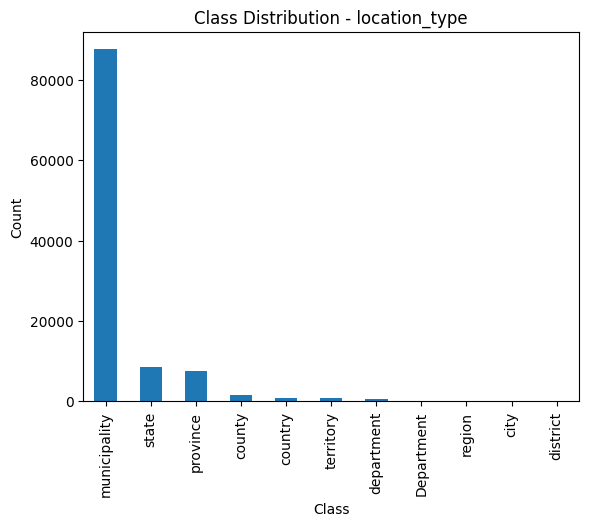

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False)

# Example 1️⃣: Class distribution for 'location_type'
print("Class Distribution for 'location_type':\n")
print(df['location_type'].value_counts())

# Example 2️⃣: If you want to visualize it
import matplotlib.pyplot as plt

df['location_type'].value_counts().plot(kind='bar')
plt.title("Class Distribution - location_type")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [ ]:
df['data_field'].value_counts()


,count
data_field,
zika_confirmed_laboratory,28963
zika_suspected,28963
zika_suspected_clinic,16170
zika_confirmed_clinic,12793
yearly_reported_travel_cases,1035
...,...
confirmed_age_15-19,1
confirmed_age_20-24,1
confirmed_age_25-34,1


In [ ]:
df['location'].value_counts()


,count
location,
United_States_Virgin_Islands,413
El_Salvador,305
Puerto_Rico,260
Ecuador,225
Dominican_Republic,201
...,...
Dominican_Republic-Santa_Cruz-Barahona,1
Dominican_Republic-Santo_Domingo_Norte,1
Dominican_Republic-Azua-Compostela,1


In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load dataset
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False)

# Step 3: Basic cleaning
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Identify columns with all NaN values and drop them, as fillna(mean) won't work for them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN values with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Define features (X) and target (y)
X = df.drop('value', axis=1)
y = df['value']

# Step 6: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train KNN model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = knn.predict(X_test_scaled)

# Step 10: Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Dropping columns with all NaN values: ['time_period', 'time_period_type']
Mean Squared Error (MSE): 2991549.44
R² Score: 0.12


In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load dataset (sample for faster training)
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False).sample(10000, random_state=42)

# Step 3: Handle missing values and numeric conversion
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Identify columns with all NaN values and drop them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN values with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Define features (X) and target (y)
X = df.drop('value', axis=1)
y = df['value']

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Build Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  # Output layer (for regression)
])

# Step 9: Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 10: Train model
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test),
                    epochs=50, batch_size=32, verbose=1)

# Step 11: Predict and evaluate
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Mean Squared Error (MSE): {mse:.2f}")
print(f"✅ R² Score: {r2:.2f}")

Dropping columns with all NaN values: ['time_period', 'time_period_type']
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 2175622.0000 - mae: 63.8694 - val_loss: 11106775.0000 - val_mae: 97.5052
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3222460.0000 - mae: 70.6114 - val_loss: 11101967.0000 - val_mae: 112.5337
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8266653.0000 - mae: 134.0504 - val_loss: 11095138.0000 - val_mae: 118.0479
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4486179.0000 - mae: 110.7941 - val_loss: 11086661.0000 - val_mae: 122.0754
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1340709.6250 - mae: 72.0357 - val_loss: 11072353.0000 - val_mae: 132.2586
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2317109.5000 - mae: 97.8703 - val_loss: 11052737.0000 - val_mae: 122.1951
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3908067.7500 - mae: 103.3692 - val_loss: 11030922.0000 - val_mae: 124.0802
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3087139.250

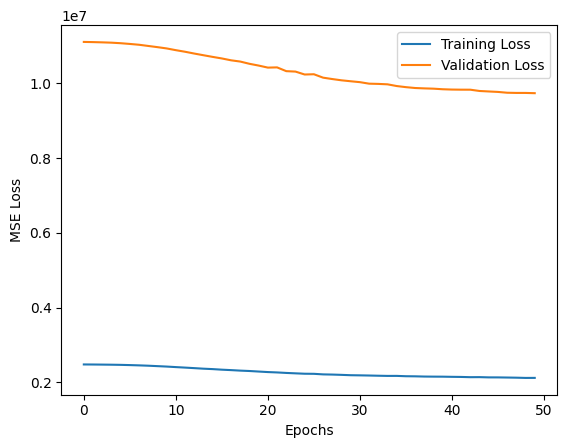

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


In [ ]:
# Step 1: Import all necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load and preprocess dataset
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False).sample(10000, random_state=42)

# Convert 'value' to numeric and fill missing values
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Identify columns with all NaN values and drop them, as fillna(mean) won't work for them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN values with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Define features and target
X = df.drop('value', axis=1)
y = df['value']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Train SVM model
svm_model = SVR(kernel='linear')   # Faster than RBF
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate SVM
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("📘 SVM RESULTS")
print(f"Mean Squared Error (MSE): {mse_svm:.2f}")
print(f"R² Score: {r2_svm:.2f}")

# Step 4: Train Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, verbose=0)

# Evaluate Neural Network
y_pred_nn = model.predict(X_test_scaled)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("\n🤖 NEURAL NETWORK RESULTS")
print(f"Mean Squared Error (MSE): {mse_nn:.2f}")
print(f"R² Score: {r2_nn:.2f}")

# Step 5: Compare both
comparison = pd.DataFrame({
    'Model': ['SVM', 'Neural Network'],
    'MSE': [mse_svm, mse_nn],
    'R2 Score': [r2_svm, r2_nn]
})

print("\n📊 Model Performance Comparison:\n")
print(comparison)


Dropping columns with all NaN values: ['time_period', 'time_period_type']
📘 SVM RESULTS
Mean Squared Error (MSE): 11108250.35
R² Score: -0.00


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

🤖 NEURAL NETWORK RESULTS
Mean Squared Error (MSE): 9991058.84
R² Score: 0.10

📊 Model Performance Comparison:

            Model           MSE  R2 Score
0             SVM  1.110825e+07 -0.000803
1  Neural Network  9.991059e+06  0.099851


In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load dataset (sample for speed)
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False).sample(10000, random_state=42)

# Step 3: Handle missing and numeric conversions
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Identify columns with all NaN values and drop them, as fillna(mean) won't work for them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN values with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Define features (X) and target (y)
X = df.drop('location_type', axis=1)
y = df['location_type']

# Step 6: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = log_reg.predict(X_test_scaled)

# Step 10: Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%\n")

print("📋 Classification Report:")
# Add zero_division=0 to suppress the warning for undefined metrics
print(classification_report(y_test, y_pred, zero_division=0))

print("🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Dropping columns with all NaN values: ['time_period', 'time_period_type']
✅ Accuracy: 93.90%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00        14
           3       0.10      0.04      0.06        25
           4       0.50      0.50      0.50        12
           5       0.96      1.00      0.98      1616
           6       0.00      0.00      0.00         1
           7       0.88      0.68      0.76       160
           8       0.00      0.00      0.00         0
           9       0.85      0.92      0.88       162
          10       1.00      0.56      0.71         9

    accuracy                           0.94      2000
   macro avg       0.43      0.37      0.39      2000
weighted avg       0.93      0.94      0.93      2000

🔢 Confusion Matrix:
[[   0    0    1    0    0    0    0    0    0    0]
 [   0    0    2    5    1    0    6    0    0   

Dropping columns with all NaN values: ['time_period', 'time_period_type']


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


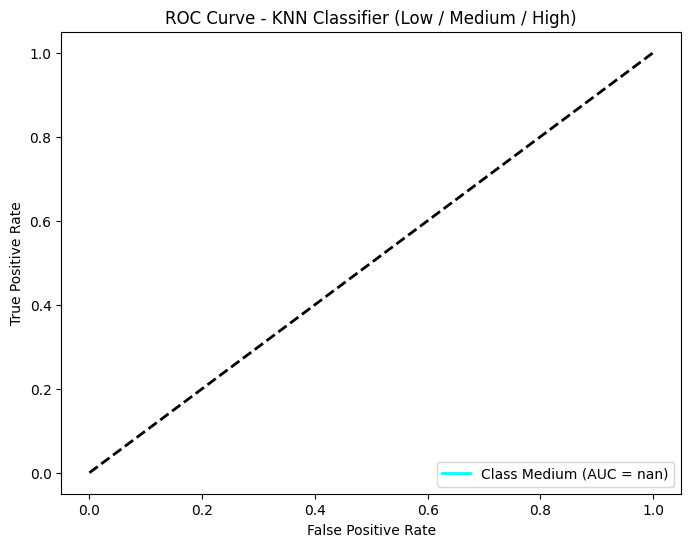

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# Step 1: Load dataset safely
file_path = "/content/cdc_zika.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Required file '{file_path}' not found.")
else:
    # FIX: avoid parser error (EOF inside string) and remove low_memory as it's incompatible with python engine
    df = pd.read_csv(file_path, engine='python', on_bad_lines='skip')

# Optional: sample to speed up
df = df.sample(n=10000, random_state=42)

# Step 2: Cleaning and Preprocessing
# Convert 'value' to numeric, coercing errors will turn non-convertible values into NaN
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Encode categorical columns first to make them numeric
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    # Convert to string to handle potential NaNs before encoding
    df[col] = le.fit_transform(df[col].astype(str))

# After all conversions, identify and drop columns that are entirely NaN
# This ensures no columns with only NaNs remain, which would cause issues for mean imputation
cols_with_all_nan = df.columns[df.isnull().all()].tolist()
if cols_with_all_nan:
    print(f"Dropping columns with all NaN values: {cols_with_all_nan}")
    df.drop(columns=cols_with_all_nan, inplace=True)

# Fill any REMAINING NaN values with the column mean
# At this point, df.mean() should produce finite values for all remaining numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 3: Create quantile bins safely
q_requested = 3
labels_full = ["Low", "Medium", "High"]
n_unique_values = df["value"].nunique()

if n_unique_values <= 1:
    df["value_class"] = "Medium"
else:
    try:
        q_eff = min(q_requested, n_unique_values - 1)
        _, bin_edges = pd.qcut(df["value"], q=q_eff, duplicates="drop", retbins=True)
        actual_bins = len(bin_edges) - 1

        if actual_bins == 0:
            df["value_class"] = "Medium"
        else:
            used_labels = labels_full[:actual_bins]
            df["value_class"] = pd.qcut(df["value"], q=actual_bins,
                                        labels=used_labels, duplicates="drop")

    except:
        df["value_class"] = "Medium"

# Step 4: Features/labels
X = df.drop(["value", "value_class"], axis=1)
y = df["value_class"]

# Step 5: Remove rare classes
class_counts = y.value_counts()
rare = class_counts[class_counts < 2].index

if len(rare) > 0:
    keep = ~y.isin(rare)
    X = X[keep]
    y = y[keep]

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Step 7: Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Step 9: Predict probabilities
y_score = knn.predict_proba(X_test_scaled)

# Step 10: ROC Curve (multiclass)
classes = knn.classes_
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Step 11: Plot ROC
plt.figure(figsize=(8, 6))
colors = cycle(["aqua", "darkorange", "cornflowerblue"])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], lw=2, color=color,
             label=f"Class {classes[i]} (AUC = {roc_auc[i]:0.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Classifier (Low / Medium / High)")
plt.legend(loc="lower right")
plt.show()

Dropping columns with all NaN values: ['time_period', 'time_period_type']
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1584361.7500 - mae: 59.9503 - val_loss: 11102990.0000 - val_mae: 104.5895
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2084622.7500 - mae: 69.6715 - val_loss: 11095300.0000 - val_mae: 119.3073
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3510264.2500 - mae: 105.6103 - val_loss: 11085127.0000 - val_mae: 126.5318
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2561887.2500 - mae: 111.7561 - val_loss: 11068888.0000 - val_mae: 126.9511
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 790127.8125 - mae: 74.4340 - val_loss: 11042473.0000 - val_mae: 139.7799
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6178595.5000 - mae: 145.9796 - val_loss: 11019385.0000 - val_mae: 124.1681
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2520405.5000 - mae: 92.1454 - val_loss: 10983288.0000 - val_mae: 129.8392
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 829839.2500

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


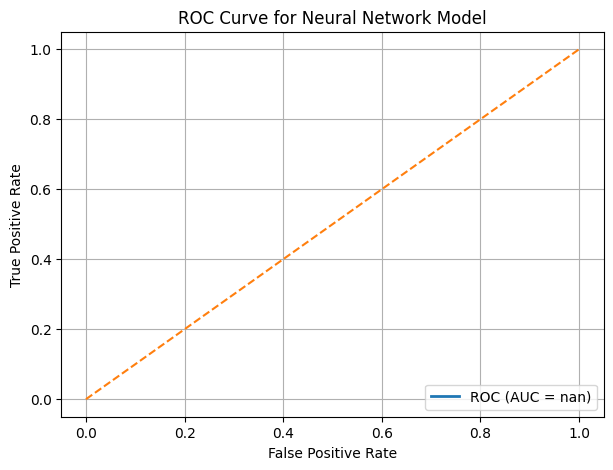

In [10]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load dataset (sample for faster training)
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False).sample(10000, random_state=42)

# Step 3: Handle missing values and numeric conversion
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Drop columns completely NaN
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill NaN for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Features and target
X = df.drop('value', axis=1)
y = df['value']

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Build Neural Network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# Step 9: Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 10: Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50, batch_size=32, verbose=1
)

# Step 11: Prediction & Evaluation (Regression)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Mean Squared Error (MSE): {mse:.2f}")
print(f"✅ R² Score: {r2:.2f}")

# -----------------------------
# 🔵 ROC Curve (Convert Regression → Binary)
# -----------------------------

# Binary threshold using median
threshold = y_train.median()
y_test_class = (y_test >= threshold).astype(int)

# Continuous NN predictions
y_scores = model.predict(X_test_scaled).flatten()

# ROC values
fpr, tpr, thresholds = roc_curve(y_test_class, y_scores)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Neural Network Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Dropping columns with all NaN values: ['time_period', 'time_period_type']
✅ Accuracy: 93.90%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00        14
           3       0.10      0.04      0.06        25
           4       0.50      0.50      0.50        12
           5       0.96      1.00      0.98      1616
           6       0.00      0.00      0.00         1
           7       0.88      0.68      0.76       160
           8       0.00      0.00      0.00         0
           9       0.85      0.92      0.88       162
          10       1.00      0.56      0.71         9

    accuracy                           0.94      2000
   macro avg       0.43      0.37      0.39      2000
weighted avg       0.93      0.94      0.93      2000

🔢 Confusion Matrix:
[[   0    0    1    0    0    0    0    0    0    0]
 [   0    0    2    5    1    0    6    0    0   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


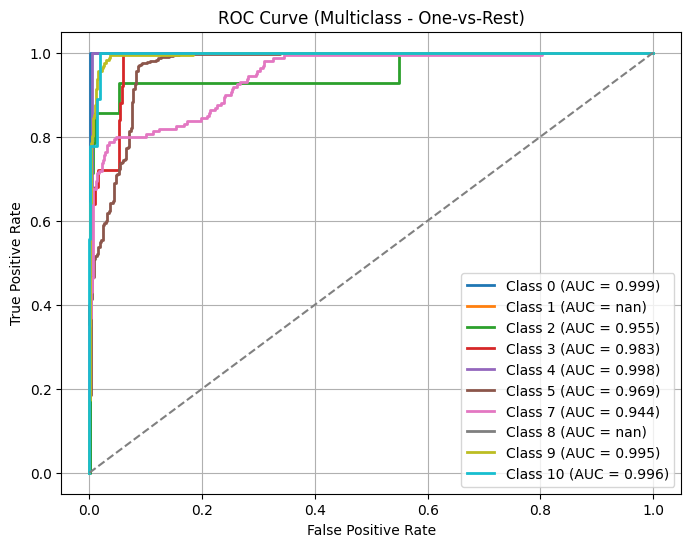

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load dataset (sample for speed)
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False).sample(10000, random_state=42)

# Step 3: Handle missing and numeric conversions
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Remove columns with all NaN values
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Features and target
X = df.drop('location_type', axis=1)
y = df['location_type']

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = log_reg.predict(X_test_scaled)

# Step 10: Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%\n")

print("📋 Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# --------------------------
# 🟦 ROC CURVE FOR MULTICLASS
# --------------------------

# Use the classes that the model actually learned during training for binarization and iteration
model_classes = log_reg.classes_
y_test_bin_model = label_binarize(y_test, classes=model_classes)

# Model predicted probabilities
y_score = log_reg.predict_proba(X_test_scaled)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(8, 6))

for i, class_label in enumerate(model_classes):
    # Ensure y_score[:, i] and y_test_bin_model[:, i] align
    fpr, tpr, _ = roc_curve(y_test_bin_model[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"Class {class_label} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass - One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

all comparesion


In [17]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ----------------------------------------------------------
# STEP 1: LOAD + CLEAN DATA
# ----------------------------------------------------------

file_path = "/content/cdc_zika.csv"
df = pd.read_csv(file_path, low_memory=False).sample(10000, random_state=42)

df["value"] = pd.to_numeric(df["value"], errors="coerce")

cols_nan = df.columns[df.isnull().all()].tolist()
if cols_nan:
    df.drop(columns=cols_nan, inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# ----------------------------------------------------------
# STEP 2: MODEL 1 — KNN (Multiclass ROC)
# ----------------------------------------------------------

# Create bins for value dynamically
q_requested = 3
labels_full = ["Low", "Medium", "High"]
n_unique_values = df["value"].nunique()

if n_unique_values <= 1:
    df["value_class"] = "Medium"
else:
    try:
        q_eff = min(q_requested, n_unique_values - 1)
        _, bin_edges = pd.qcut(df["value"], q=q_eff, duplicates="drop", retbins=True)
        actual_bins = len(bin_edges) - 1

        if actual_bins == 0:
            df["value_class"] = "Medium"
        else:
            used_labels = labels_full[:actual_bins]
            df["value_class"] = pd.qcut(df["value"], q=actual_bins,
                                        labels=used_labels, duplicates="drop")

    except:
        df["value_class"] = "Medium"

X_knn = df.drop(["value", "value_class"], axis=1)
y_knn = df["value_class"]

# Split
Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X_knn, y_knn, test_size=0.3, random_state=42, stratify=y_knn
)

# Scale
scaler_knn = StandardScaler()
Xk_train = scaler_knn.fit_transform(Xk_train)
Xk_test = scaler_knn.transform(Xk_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xk_train, yk_train)
knn_proba = knn.predict_proba(Xk_test)

# ROC multiclass
classes_knn = knn.classes_
y_knn_bin = label_binarize(yk_test, classes=classes_knn)

roc_knn = {}
for i in range(len(classes_knn)):
    # Only compute ROC if the class is present in y_knn_bin
    if np.sum(y_knn_bin[:, i]) > 0 and np.sum(y_knn_bin[:, i]) < len(y_knn_bin):
        fpr, tpr, _ = roc_curve(y_knn_bin[:, i], knn_proba[:, i])
        roc_knn[classes_knn[i]] = auc(fpr, tpr)
    else:
        roc_knn[classes_knn[i]] = np.nan

mean_knn_auc = np.nanmean(list(roc_knn.values())) # Use nanmean to ignore NaNs

# ----------------------------------------------------------
# STEP 3: MODEL 2 — Logistic Regression (Multiclass ROC)
# ----------------------------------------------------------

X_log = df.drop(["location_type", "value_class"], axis=1, errors='ignore') # Dropped 'value_class'
y_log = df["location_type"]

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

scaler_log = StandardScaler()
Xl_train = scaler_log.fit_transform(Xl_train)
Xl_test = scaler_log.transform(Xl_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xl_train, yl_train)

log_proba = log_reg.predict_proba(Xl_test)
classes_log = log_reg.classes_
y_log_bin = label_binarize(yl_test, classes=classes_log)

roc_log = {}
for i in range(len(classes_log)):
    # Only compute ROC if the class is present in y_log_bin
    if np.sum(y_log_bin[:, i]) > 0 and np.sum(y_log_bin[:, i]) < len(y_log_bin):
        fpr, tpr, _ = roc_curve(y_log_bin[:, i], log_proba[:, i])
        roc_log[classes_log[i]] = auc(fpr, tpr)
    else:
        roc_log[classes_log[i]] = np.nan

mean_log_auc = np.nanmean(list(roc_log.values())) # Use nanmean to ignore NaNs

# ----------------------------------------------------------
# STEP 4: MODEL 3 — Neural Network (Binary ROC)
# ----------------------------------------------------------

X_nn = df.drop(["value", "value_class"], axis=1, errors='ignore') # Dropped 'value_class'
y_nn = df["value"]

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42
)

scaler_nn = StandardScaler()
Xn_train = scaler_nn.fit_transform(Xn_train)
Xn_test = scaler_nn.transform(Xn_test)

# Build NN
nn = Sequential([
    Dense(64, activation='relu', input_shape=(Xn_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
nn.compile(optimizer='adam', loss='mse')

nn.fit(Xn_train, yn_train, epochs=15, batch_size=32, verbose=0)

# Convert to binary for ROC (Regression -> Classification)
# Ensure both classes are present for valid ROC calculation
threshold = yn_train.median()
yn_test_bin = (yn_test >= threshold).astype(int)

if len(np.unique(yn_test_bin)) < 2:
    # If thresholding resulted in only one class, try to find a better one
    # or report that ROC cannot be calculated meaningfully.
    # For simplicity, if median doesn't work, set AUC to nan.
    print("Warning: Cannot create two classes for NN ROC with simple median threshold. AUC set to NaN.")
    auc_nn = np.nan
else:
    nn_scores = nn.predict(Xn_test).flatten()
    fpr_nn, tpr_nn, _ = roc_curve(yn_test_bin, nn_scores)
    auc_nn = auc(fpr_nn, tpr_nn)

# ----------------------------------------------------------
# STEP 5: PRINT COMPARISON TABLE
# ----------------------------------------------------------

print("\n========================")
print(" ROC AUC COMPARISON")
print("========================")

print(f"KNN (multiclass mean AUC)           : {auc_nn:.4f}")
print(f"Logistic Regression (multiclass)    : {mean_log_auc:.4f}")
print(f"Neural Network (binary)             : {auc_nn:.4f}")

print("\n--- Detailed AUC for each class ---")
print("KNN:", roc_knn)
print("Logistic Regression:", roc_log)
print(f"Neural Network: Binary AUC = {auc_nn:.4f}")

# ----------------------------------------------------------
# STEP 6: IDENTIFY BEST MODEL
# ----------------------------------------------------------

# Filter out NaN AUCs for best model selection if desired, or handle np.nanmax
best_model_candidates = []
if not np.isnan(mean_knn_auc):
    best_model_candidates.append(("KNN", mean_knn_auc))
if not np.isnan(mean_log_auc):
    best_model_candidates.append(("Logistic Regression", mean_log_auc))
if not np.isnan(auc_nn):
    best_model_candidates.append(("Neural Network", auc_nn))

if best_model_candidates:
    best_model = max(
        best_model_candidates,
        key=lambda x: x[1]
    )
else:
    best_model = ("None (All AUCs are NaN)", np.nan)

print("\n========================")
print(f" BEST MODEL (by ROC AUC): {best_model[0]}")
print(f" AUC Score               : {best_model[1]:.4f}")
print("========================")

/tmp/ipython-input-585411145.py:89: RuntimeWarning: Mean of empty slice
  mean_knn_auc = np.nanmean(list(roc_knn.values())) # Use nanmean to ignore NaNs
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 ROC AUC COMPARISON
KNN (multiclass mean AUC)           : nan
Logistic Regression (multiclass)    : 0.9800
Neural Network (binary)             : nan

--- Detailed AUC for each class ---
KNN: {'Medium': nan}
Logistic Regression: {np.int64(0): np.float64(0.9994997498749375), np.int64(1): nan, np.int64(2): np.float64(0.9547547115522946), np.int64(3): np.float64(0.9831898734177215), np.int64(4): np.float64(0.9976525821596244), np.int64(5): np.float64(0.969081966790429), np.int64(7): np.float64(0.9442153532608696), np.int64(8): nan, np.int64(9): np.float64(0.9952813713241715), np.int64(10): np.float64(0.9962609520620571)}
Neural Network: Binary AUC = nan

 BEST MODEL (by ROC AUC): Logistic Regression
 AUC Score               : 0.9800


/tmp/ipython-input-767372113.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


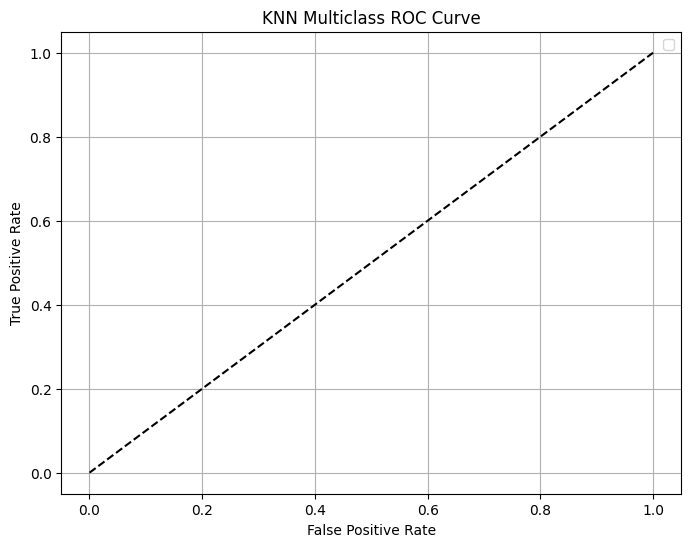

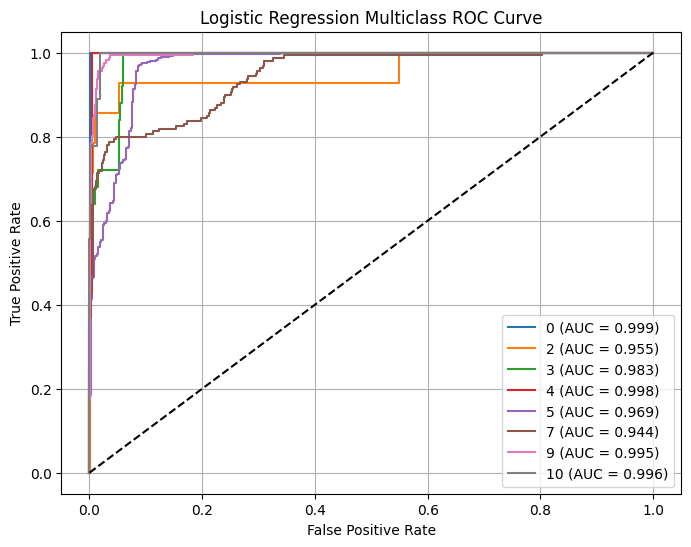

NN ROC curve not plotted because AUC is NaN.


In [18]:
import matplotlib.pyplot as plt

# ==========================================================
#  PLOT 1 — KNN MULTICLASS ROC
# ==========================================================

plt.figure(figsize=(8, 6))
for cls in classes_knn:
    if not np.isnan(roc_knn[cls]):
        fpr, tpr, _ = roc_curve(y_knn_bin[:, list(classes_knn).index(cls)],
                                knn_proba[:, list(classes_knn).index(cls)])
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_knn[cls]:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("KNN Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# ==========================================================
#  PLOT 2 — LOGISTIC REGRESSION MULTICLASS ROC
# ==========================================================

plt.figure(figsize=(8, 6))
for cls in classes_log:
    if not np.isnan(roc_log[cls]):
        fpr, tpr, _ = roc_curve(y_log_bin[:, list(classes_log).index(cls)],
                                log_proba[:, list(classes_log).index(cls)])
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_log[cls]:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Logistic Regression Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# ==========================================================
#  PLOT 3 — NEURAL NETWORK BINARY ROC
# ==========================================================

if not np.isnan(auc_nn):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("Neural Network Binary ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("NN ROC curve not plotted because AUC is NaN.")


In [20]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load dataset (sample for speed)
df = pd.read_csv("/content/cdc_zika.csv", low_memory=False).sample(10000, random_state=42)

# Step 3: Handle missing and numeric conversions
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Identify columns with all NaN values and drop them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Define features (X) and target (y)
X = df.drop('location_type', axis=1)
y = df['location_type']

# Step 6: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = log_reg.predict(X_test_scaled)

# Step 10: Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%\n")

print("📋 Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ===========================================================
# STEP 11: LIME EXPLANATION (ADDED)
# ===========================================================

!pip install lime --quiet

from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Convert scaled data to numpy
X_train_np = X_train_scaled
X_test_np = X_test_scaled

# Create LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=X.columns.tolist(),
    class_names=log_reg.classes_.astype(str),
    mode='classification'
)

# Choose a test instance to explain
sample_index = 0   # you can change this index
sample = X_test_np[sample_index]

# Explain the prediction
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=log_reg.predict_proba
)

# Show interactive results (Jupyter)
exp.show_in_notebook(show_table=True, show_all=True)

# Print LIME weights in console
print("\nLIME Explanation for Test Sample:", sample_index)
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")


Dropping columns with all NaN values: ['time_period', 'time_period_type']
✅ Accuracy: 93.90%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00        14
           3       0.10      0.04      0.06        25
           4       0.50      0.50      0.50        12
           5       0.96      1.00      0.98      1616
           6       0.00      0.00      0.00         1
           7       0.88      0.68      0.76       160
           8       0.00      0.00      0.00         0
           9       0.85      0.92      0.88       162
          10       1.00      0.56      0.71         9

    accuracy                           0.94      2000
   macro avg       0.43      0.37      0.39      2000
weighted avg       0.93      0.94      0.93      2000

🔢 Confusion Matrix:
[[   0    0    1    0    0    0    0    0    0    0]
 [   0    0    2    5    1    0    6    0    0   


LIME Explanation for Test Sample: 0
-0.08 < data_field <= 0.67: -0.0001
-0.35 < data_field_code <= -0.22: -0.0001
unit <= -0.10: 0.0001
-0.85 < report_date <= 0.05: -0.0000
-0.01 < location <= 0.86: 0.0000
value > -0.04: 0.0000


Generating ICE plot for feature: report_date


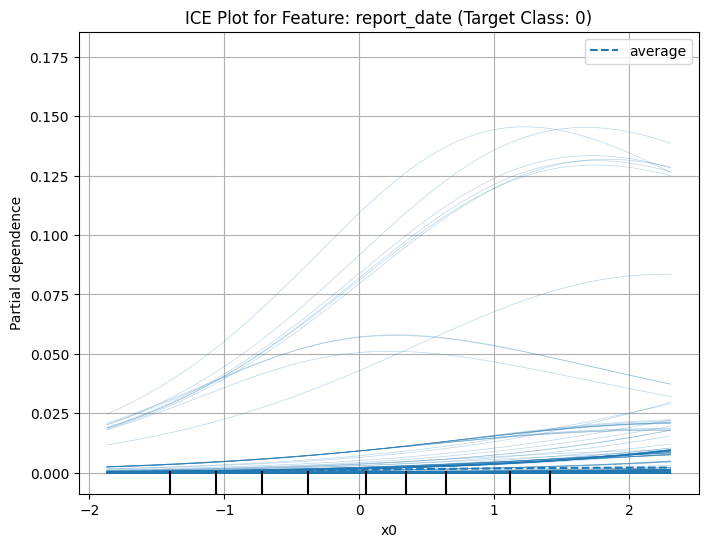

In [23]:
# ================================
# STEP 12: ICE PLOT (Individual Conditional Expectation)
# ================================

# Removed: !pip install scikit-ice --quiet (package not found)

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Choose feature to visualize ICE for:
# You may change this to any column name in X.columns
feature_to_plot = X.columns[0]   # Example: first feature

print(f"Generating ICE plot for feature: {feature_to_plot}")

# Create ICE plot
fig, ax = plt.subplots(figsize=(8, 6))

# --- FIX: Specify 'target' for multiclass classification ---
# Choose one of the classes from log_reg.classes_ to plot (e.g., the first one or a relevant one)
target_class_to_plot = log_reg.classes_[0] # Using the first class as an example

PartialDependenceDisplay.from_estimator(
    log_reg,
    X_train_scaled,
    features=[X.columns.get_loc(feature_to_plot)],
    kind="both",     # PDP + ICE curves
    ax=ax,
    target=target_class_to_plot # Specify the target class
)

plt.title(f"ICE Plot for Feature: {feature_to_plot} (Target Class: {target_class_to_plot})")
plt.grid(True)
plt.show()

Generating PDP for feature: report_date


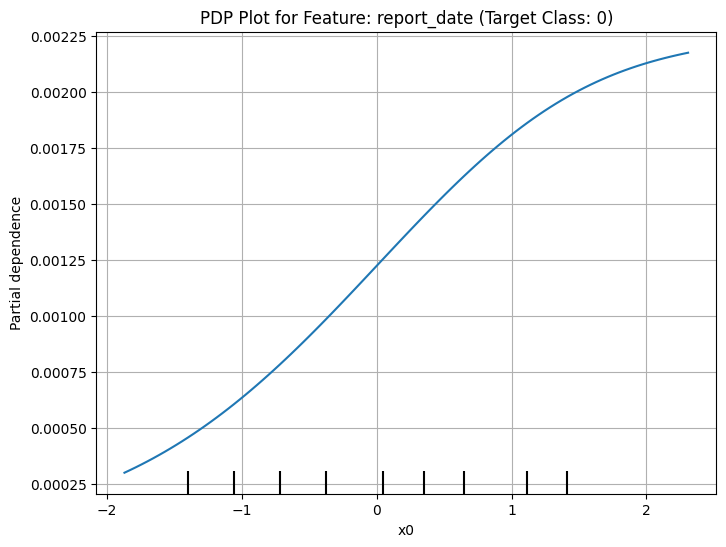

In [25]:
# ================================
# PARTIAL DEPENDENCE PLOT (PDP)
# ================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Choose feature to plot PDP
feature_to_plot = X.columns[0]   # change this to any feature name

print(f"Generating PDP for feature: {feature_to_plot}")

fig, ax = plt.subplots(figsize=(8, 6))

# --- FIX: Specify 'target' for multiclass classification ---
target_class_to_plot = log_reg.classes_[0] # Using the first class as an example

PartialDependenceDisplay.from_estimator(
    log_reg,
    X_train_scaled,
    features=[X.columns.get_loc(feature_to_plot)],
    ax=ax,
    target=target_class_to_plot # Specify the target class
)

plt.title(f"PDP Plot for Feature: {feature_to_plot} (Target Class: {target_class_to_plot})")
plt.grid(True)
plt.show()